# Optimización: SVM en Dry Bean (notebook corregido)

Este cuaderno sigue el **PDF del informe como especificación principal** y toma el notebook de `cruz-eng/ml-opti` como avance inicial.

La idea, explicada fácil: imaginemos que cada frijol es un punto. Una SVM intenta poner una cerca entre variedades dejando el pasillo más ancho posible. `C` decide cuánto castiga los errores y `gamma` decide qué tan curva puede ser la cerca RBF.

Reglas de este experimento:

- se quitan los 68 duplicados antes de separar datos;
- no se imputa nada porque no hay faltantes;
- el 20 % de test se guarda como un examen cerrado;
- la selección usa CV estratificada de 5 pliegues solo en entrenamiento;
- la pareja binaria se elige por confusión OOF de entrenamiento;
- todas las tablas salen de resultados calculados, no de números escritos a mano.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

RUN_EXPERIMENTS = False  # Cambia a True para recalcular E1--E5.
if RUN_EXPERIMENTS:
    from src.experiments import run_all
    metrics = run_all(ROOT)
else:
    metrics = json.loads((ROOT / "results" / "metrics.json").read_text(encoding="utf-8"))

print("Carpeta del proyecto:", ROOT)
print("Resultados cargados:", not RUN_EXPERIMENTS)

Carpeta del proyecto: C:\Users\leona\Documents\Codex\2026-09-20\https-github-com-gg-369-proyecto\work\optimizacion-target
Resultados cargados: True


## 1. Datos y limpieza

Cada fila representa un frijol y las 16 columnas numéricas son medidas geométricas extraídas de imágenes. `Class` es la variedad que queremos predecir.

Los duplicados son como entregar exactamente la misma tarjeta dos veces: pueden favorecer artificialmente al modelo si una copia cae en entrenamiento y otra en test. Por eso se eliminan **antes** de dividir.

,concepto,valor
0,Filas originales,13611
1,Duplicados exactos,68
2,Filas analíticas,13543
3,Variables,16
4,Faltantes,0


,original,después_de_limpieza
Class,,
BARBUNYA,1322,1322
BOMBAY,522,522
CALI,1630,1630
DERMASON,3546,3546
HOROZ,1928,1860
SEKER,2027,2027
SIRA,2636,2636


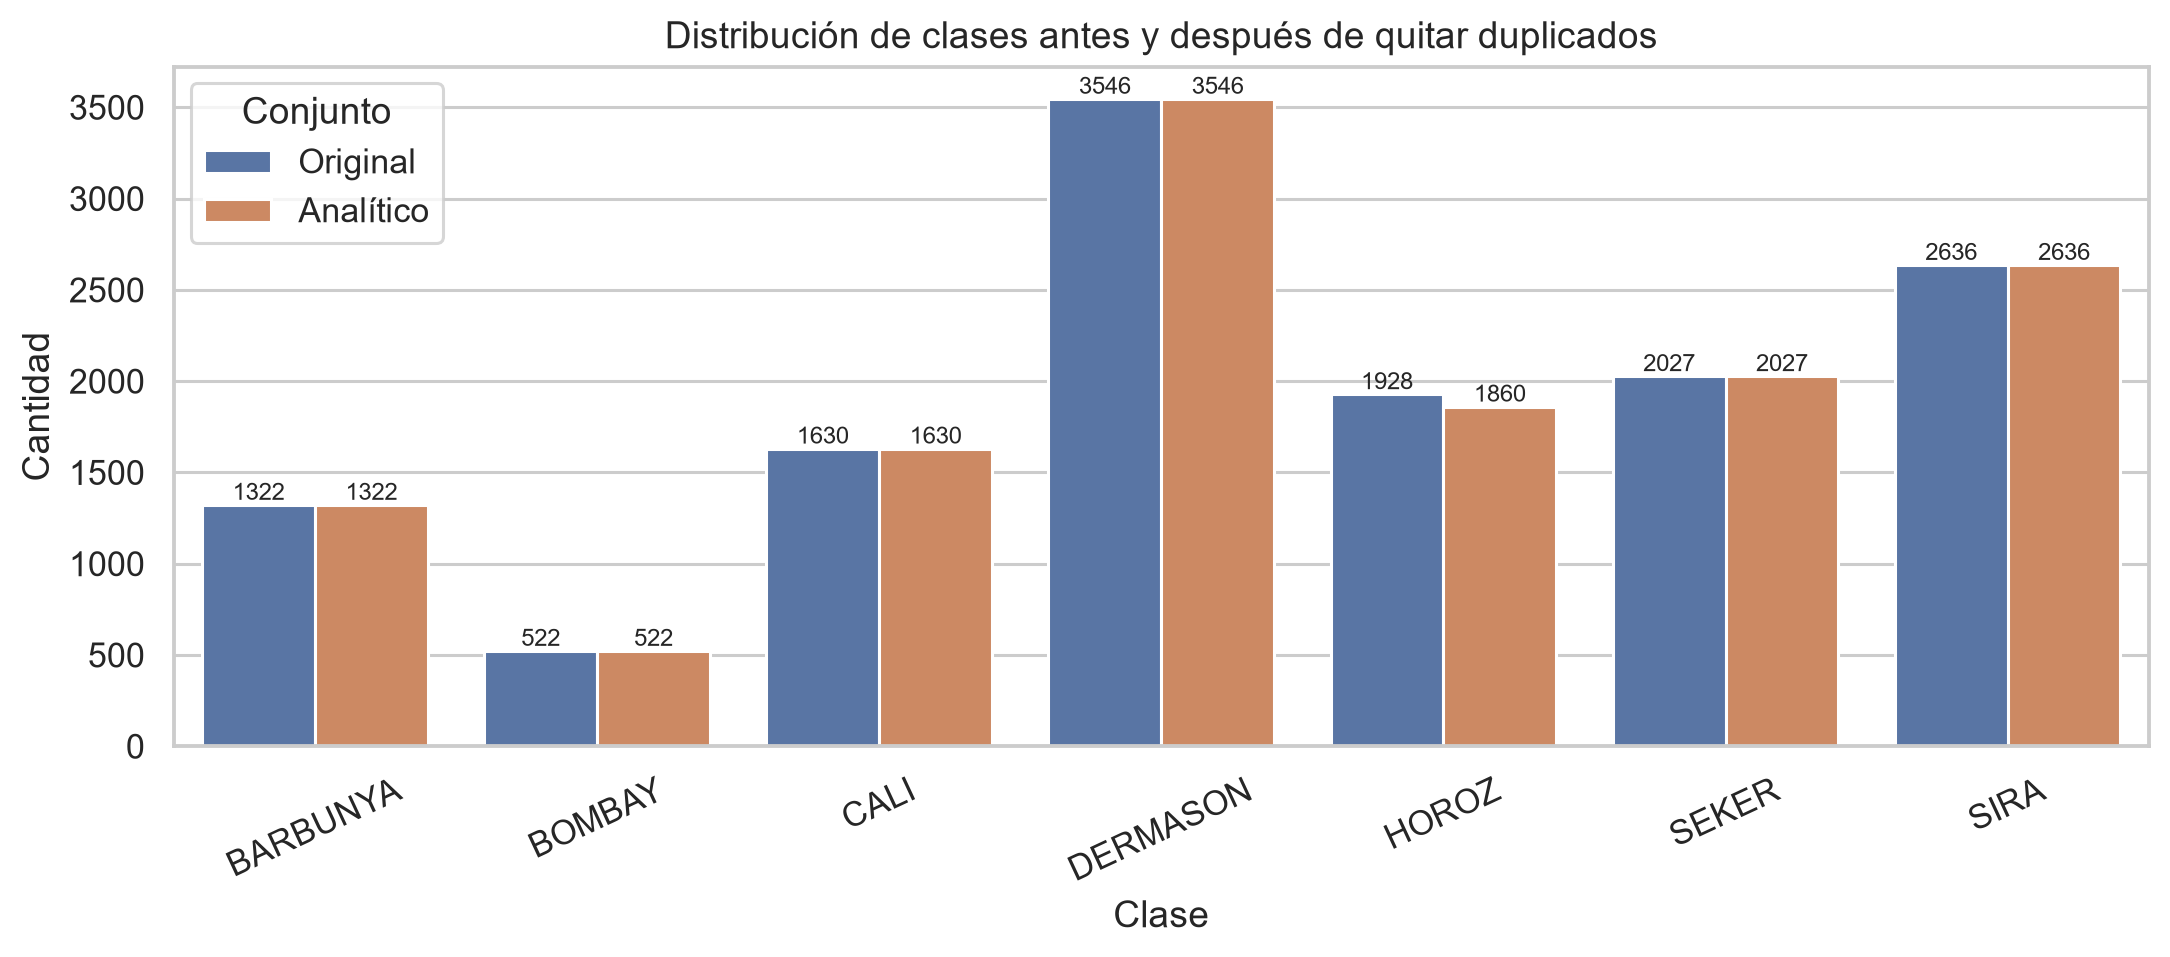

In [2]:
raw = pd.read_excel(ROOT / "data" / "Dry_Bean_Dataset.xlsx")
df = raw.drop_duplicates().reset_index(drop=True)

resumen_datos = pd.DataFrame({
    "concepto": ["Filas originales", "Duplicados exactos", "Filas analíticas", "Variables", "Faltantes"],
    "valor": [len(raw), int(raw.duplicated().sum()), len(df), raw.shape[1] - 1, int(raw.isna().sum().sum())]
})
display(resumen_datos)

conteos = pd.DataFrame({
    "original": raw["Class"].value_counts(),
    "después_de_limpieza": df["Class"].value_counts(),
}).sort_index()
display(conteos)
display(Image(filename=str(ROOT / "figures" / "01_distribucion_clases.png"), width=900))

**Lectura:** las 68 copias pertenecían a HOROZ. Por eso el total baja de 13 611 a 13 543 y HOROZ de 1 928 a 1 860. Como hay cero faltantes, añadir imputación por mediana no transformaría nada; se retiró para que código e informe digan lo mismo.

Las siguientes figuras son descriptivas. La PCA ayuda a mirar los grupos, pero no se usa como entrada de la SVM.

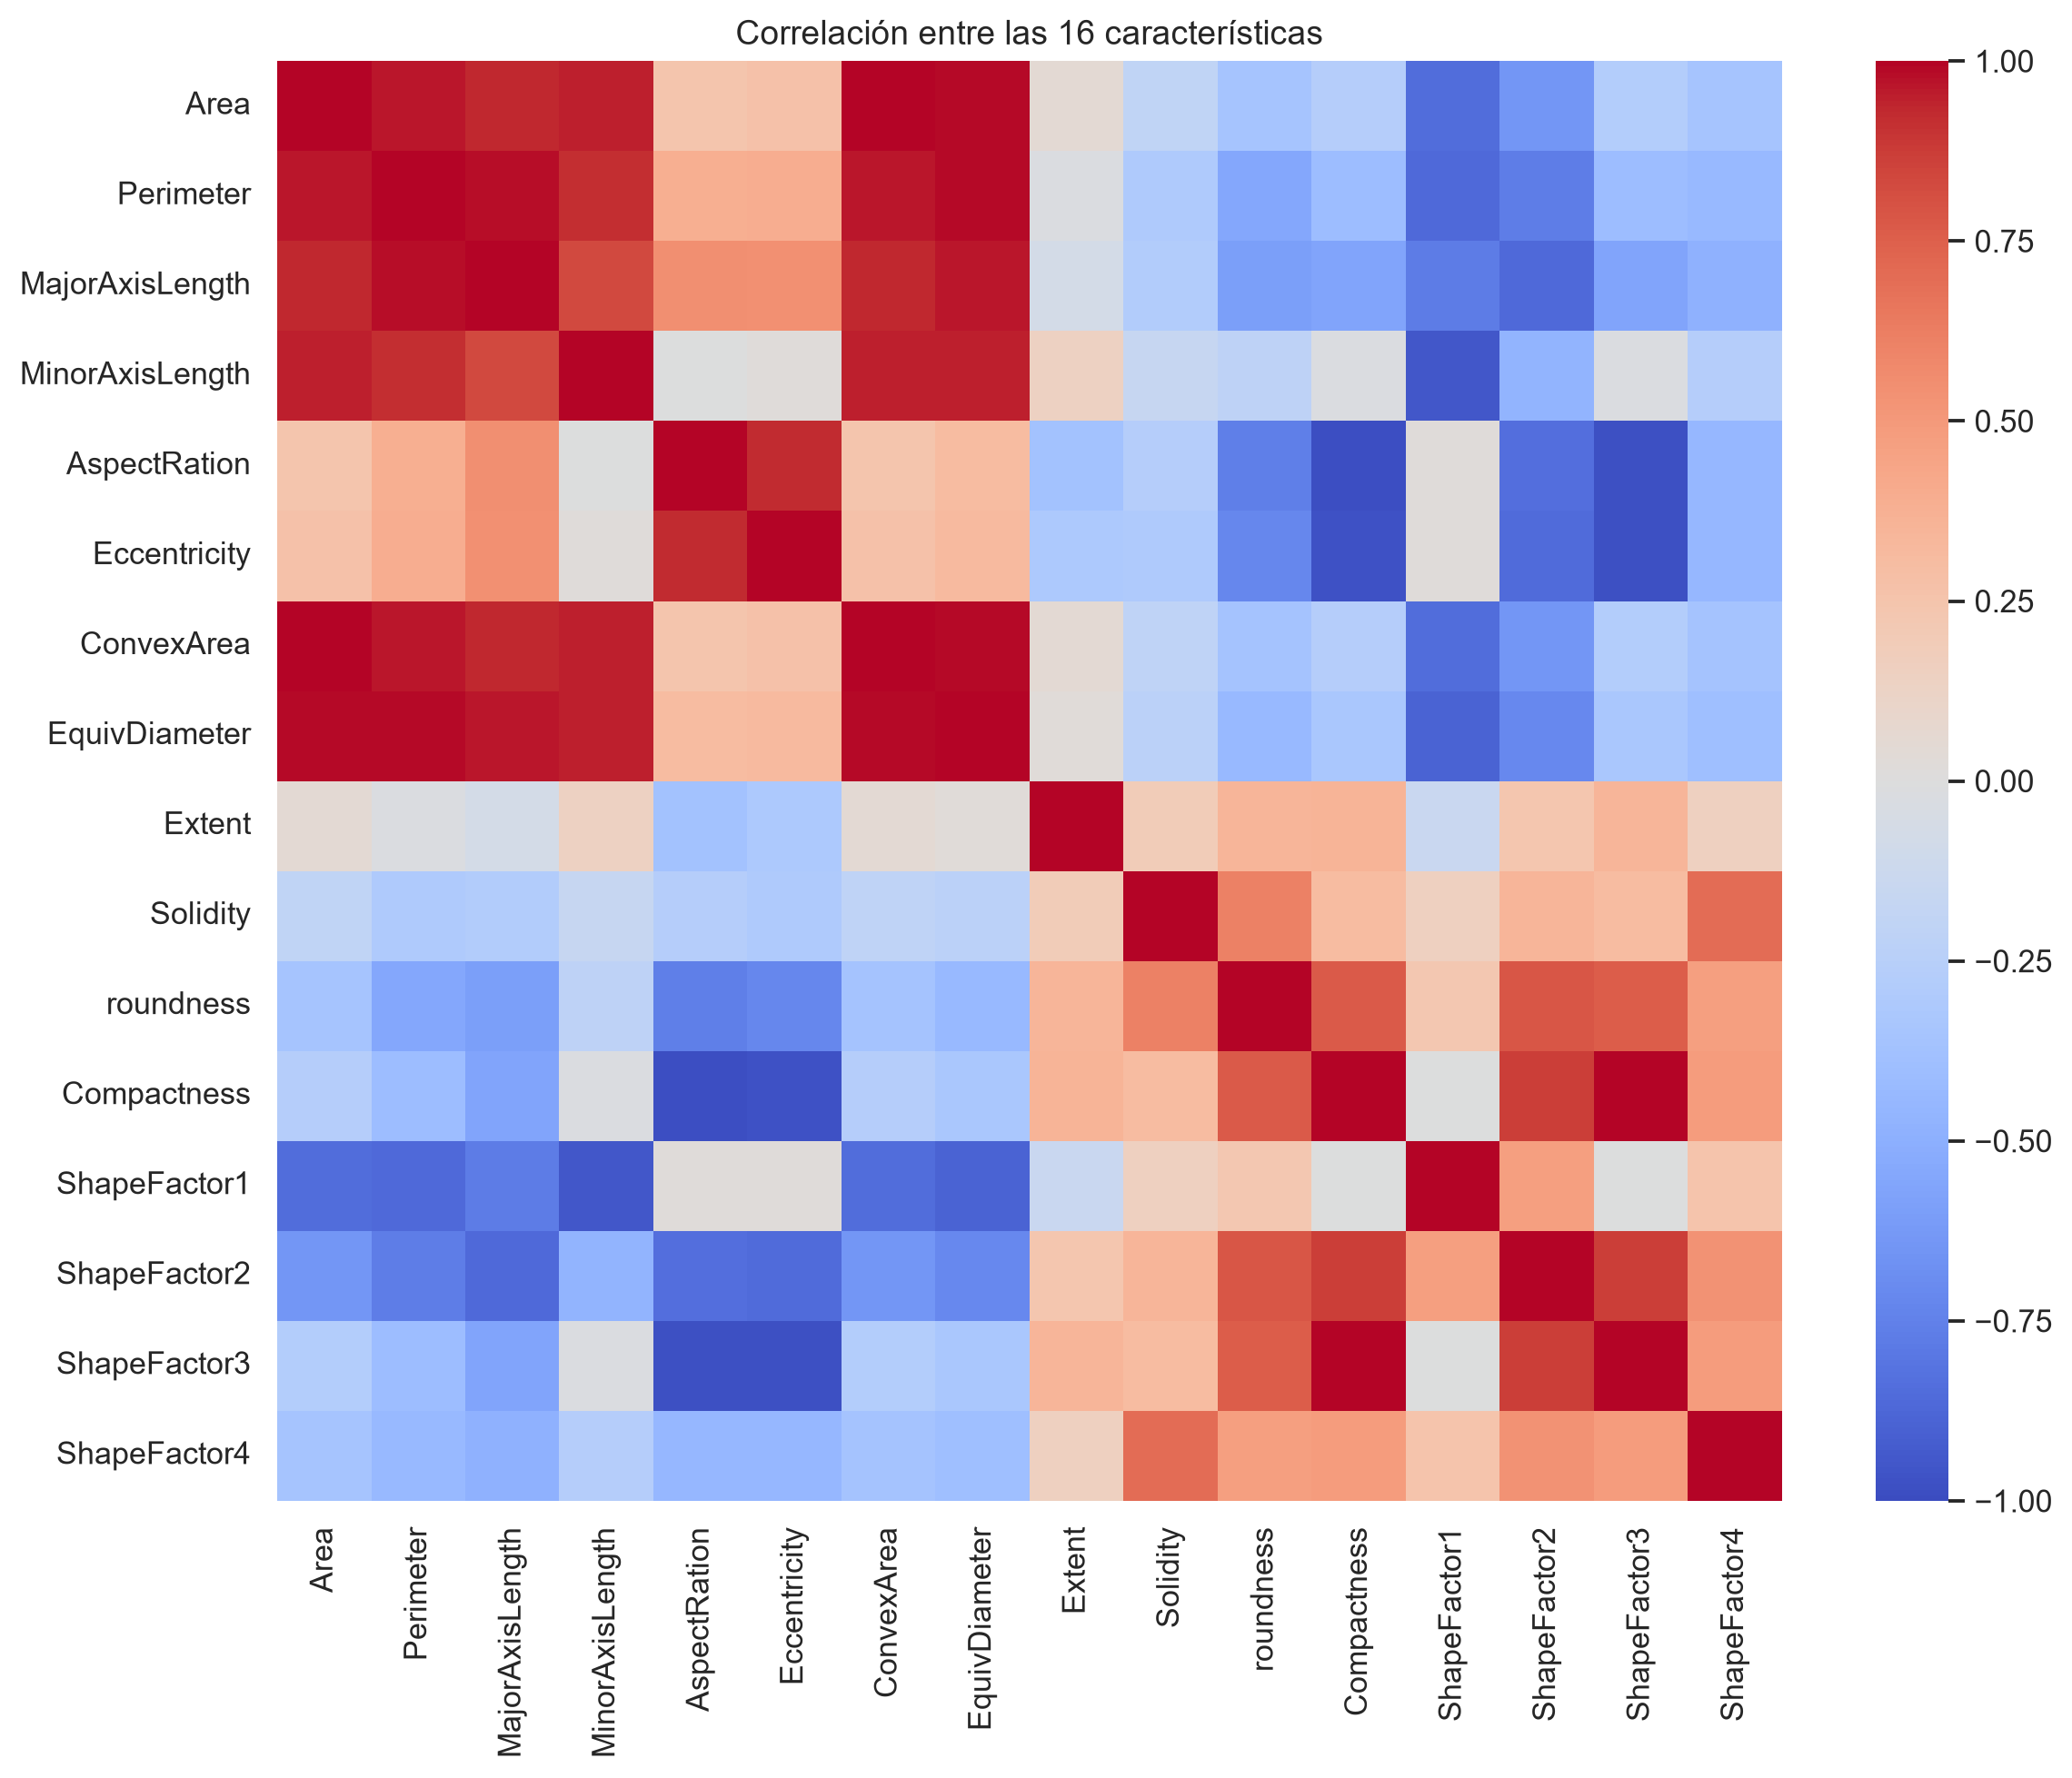

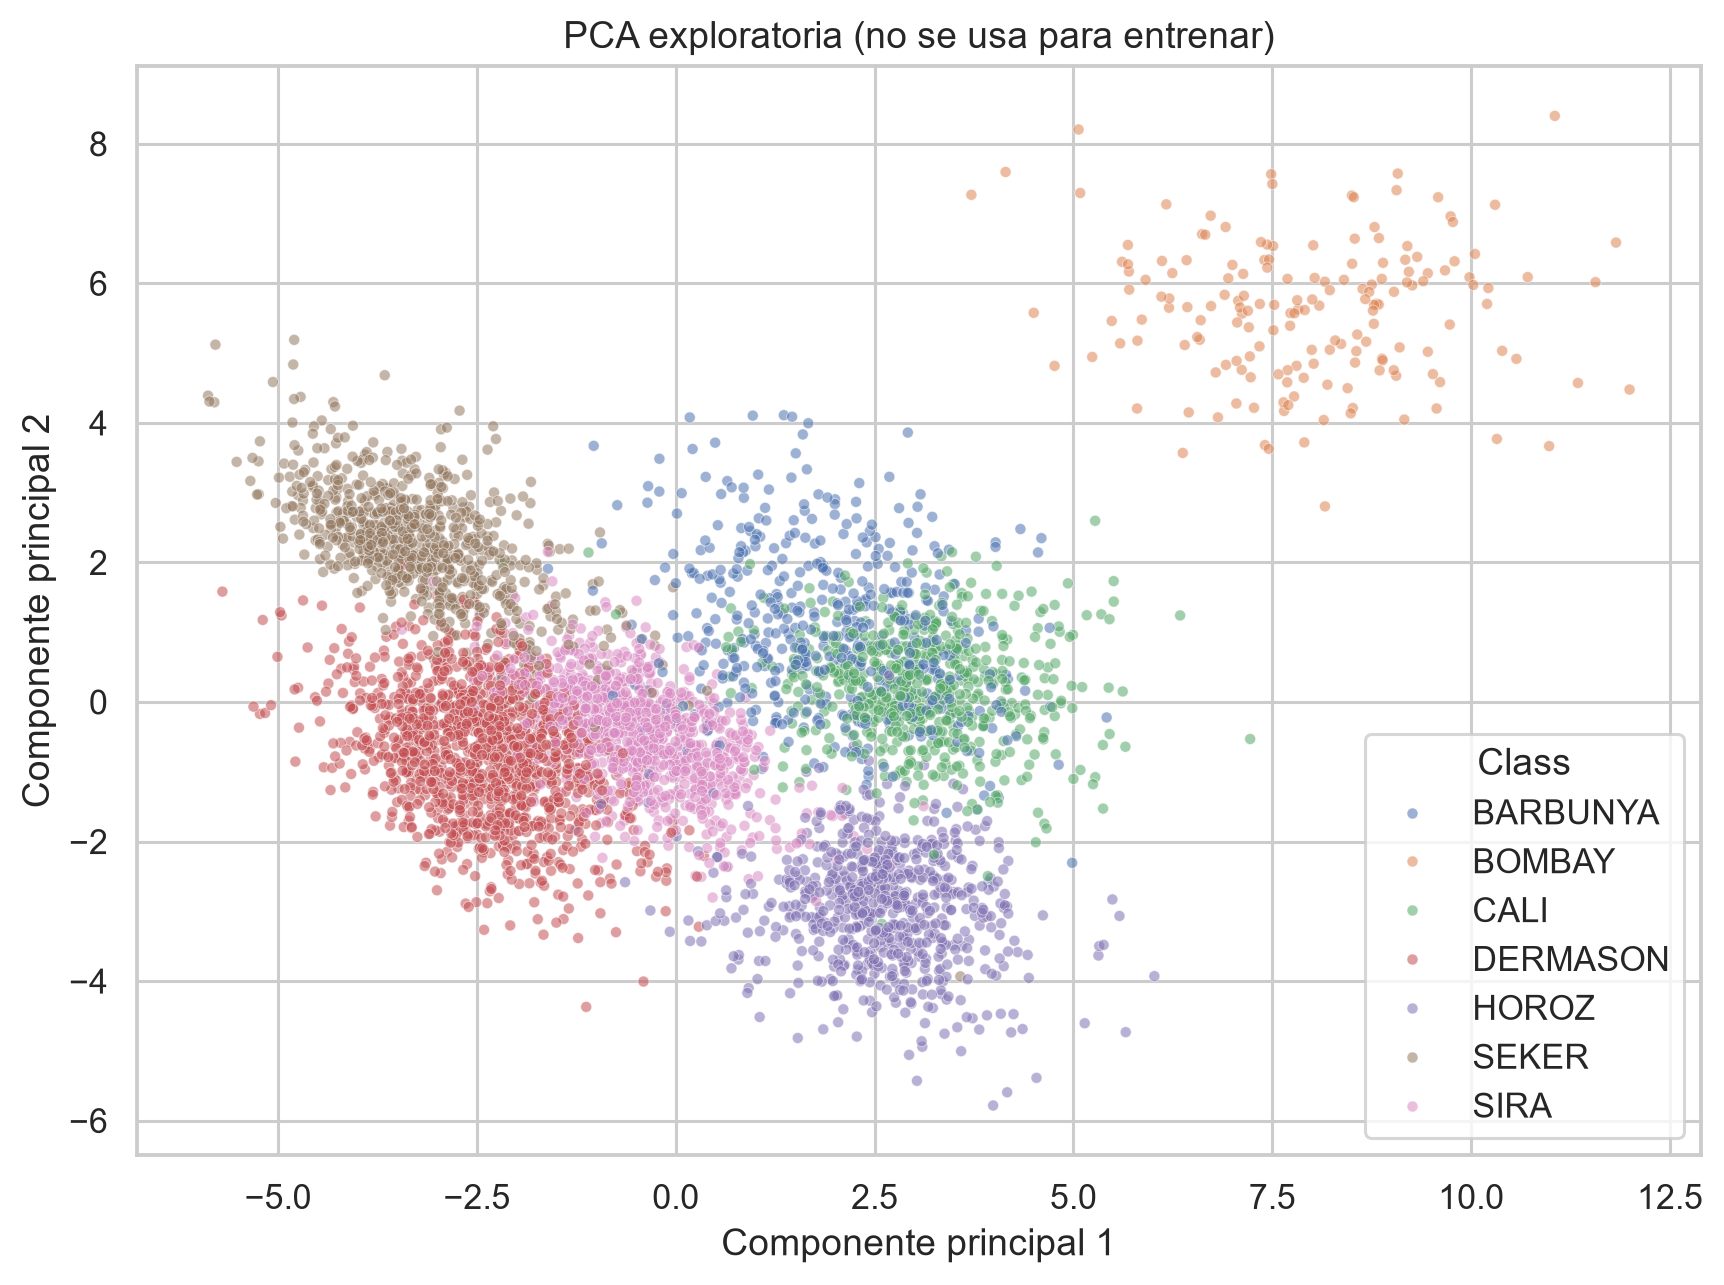

In [3]:
display(Image(filename=str(ROOT / "figures" / "02_correlaciones.png"), width=850))
display(Image(filename=str(ROOT / "figures" / "03_pca_exploratoria.png"), width=750))

## 2. Diseño experimental y correcciones prioritarias

La búsqueda RBF es escalonada en potencias de 2: una malla gruesa cubre ampliamente el espacio y una segunda malla prueba los exponentes vecinos del ganador. Es la versión reproducible y computacionalmente razonable de la rejilla amplia propuesta en el Hito I.

In [4]:
ajustes = pd.DataFrame([
    ["Duplicados", "No se limpiaban", "Eliminar 68 antes del split"],
    ["Faltantes", "Imputación implícita/propuesta", "Sin imputación: hay 0 faltantes"],
    ["Validación", "Parámetros pequeños o cifras manuales", "5-fold estratificado y tablas calculadas"],
    ["Pareja binaria", "SEKER–SIRA fijada a mano", "Mayor confusión OOF del entrenamiento"],
    ["SMO", "Segunda variable aleatoria", "Pareja de máxima violación; parada m-M"],
    ["Multiclase", "Alcance poco claro", "OvR/OvO propios en demo; SVC en conjunto completo"],
    ["E4", "Faltaba lectura completa", "Accuracy, F1 macro y número de SV"],
    ["E5", "Un cronometraje", "3 repeticiones, mediana, IQR, theta y R²"],
], columns=["Tema", "Antes", "Corrección"])
display(ajustes)

display(pd.Series(metrics["split"], name="partición").to_frame())
display(pd.Series(metrics["multiclass_cv"], name="mejor RBF por CV").to_frame())

,Tema,Antes,Corrección
0,Duplicados,No se limpiaban,Eliminar 68 antes del split
1,Faltantes,Imputación implícita/propuesta,Sin imputación: hay 0 faltantes
2,Validación,Parámetros pequeños o cifras manuales,5-fold estratificado y tablas calculadas
3,Pareja binaria,SEKER–SIRA fijada a mano,Mayor confusión OOF del entrenamiento
4,SMO,Segunda variable aleatoria,Pareja de máxima violación; parada m-M
5,Multiclase,Alcance poco claro,OvR/OvO propios en demo; SVC en conjunto completo
6,E4,Faltaba lectura completa,"Accuracy, F1 macro y número de SV"
7,E5,Un cronometraje,"3 repeticiones, mediana, IQR, theta y R²"


,partición
train,10834
test,2709
test_fraction,0.2
stratified,True
seed,42
cv_folds,5


,mejor RBF por CV
best_C,64.000000
best_gamma,0.015625
best_cv_f1_macro,0.944807
best_cv_accuracy,0.933358


## 3. E1 — SMO propio frente a LIBSVM

SMO resuelve el problema dual cambiando dos multiplicadores `alpha` por vez. La condición `sum(y_i alpha_i)=0` se conserva en cada paso. El algoritmo propio prueba kernels lineal, polinomial y RBF y elige la pareja con mayor violación KKT.

Cómo leer la comparación:

- los objetivos duales deben ser casi iguales;
- `m - M` debe quedar por debajo de la tolerancia `0.001`;
- el residuo de igualdad debe estar cerca de cero;
- la concordancia de predicciones debe acercarse a 1.

,valor
n_subset,400
C,8.0
gamma,0.003906
iterations,254
converged,True
m,-1.90781
M,-1.908737
m_minus_M,0.000926
equality_residual,0.0
dual_own,636.552729


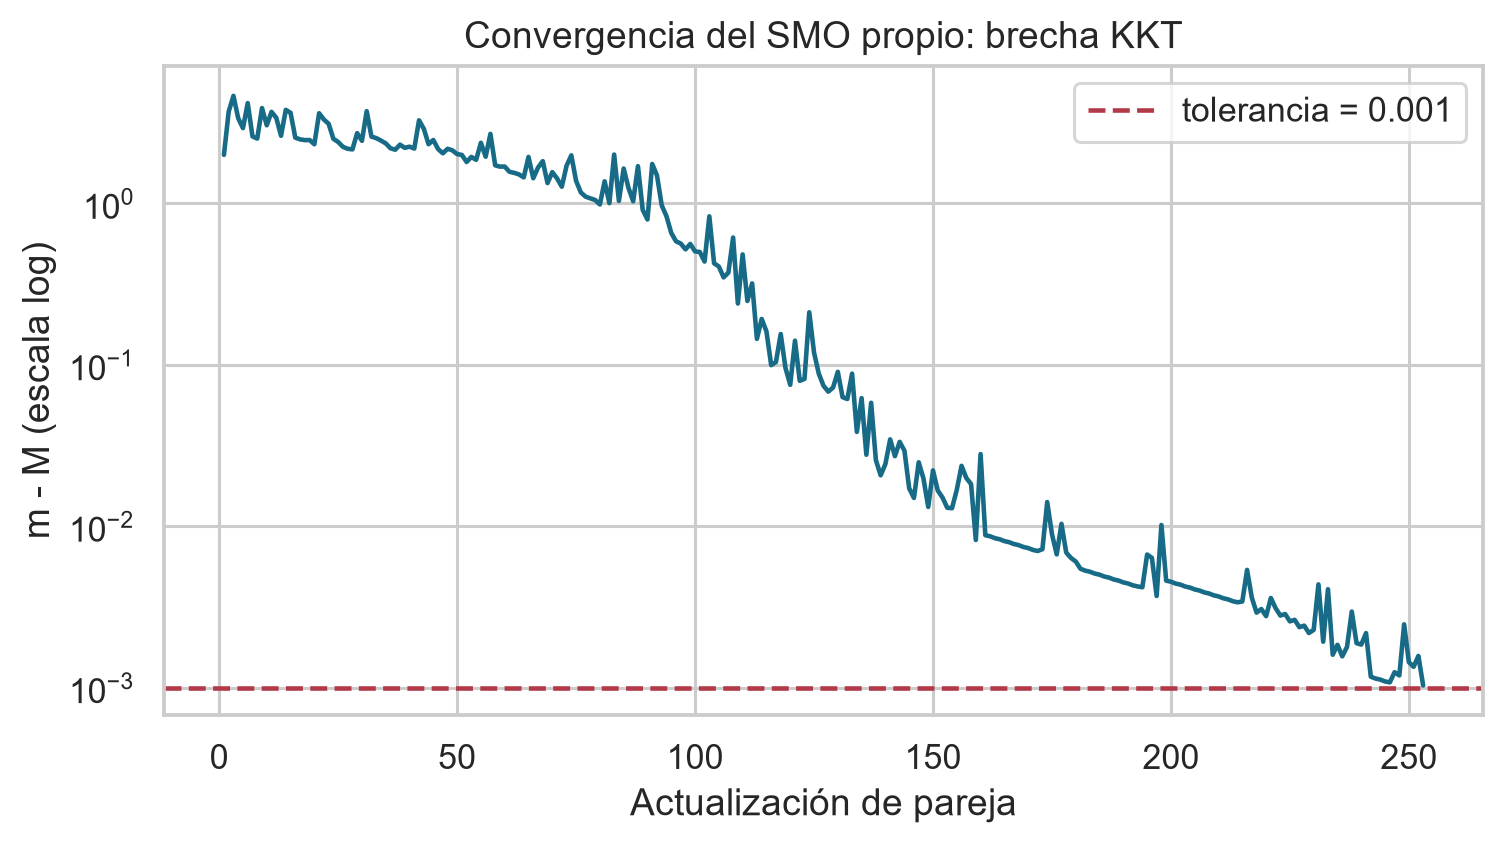

In [5]:
e1 = pd.read_csv(ROOT / "results" / "e1_smo_vs_libsvm.csv")
display(e1.T.rename(columns={0: "valor"}))
display(Image(filename=str(ROOT / "figures" / "06_convergencia_smo.png"), width=750))

**Interpretación:** el SMO propio converge y reproduce la solución de LIBSVM en el subconjunto de verificación. Esto valida la implementación didáctica; no significa que el entrenamiento completo sea más rápido que LIBSVM.

## 4. E2 — Comparación binaria de kernels

Antes de formar el problema binario se entrena el mejor RBF multiclase mediante predicciones OOF: cada fila es predicha por un modelo que no la vio. Se suma la confusión en ambas direcciones para cada pareja y se elige la mayor. El test nunca participa en esta elección.

,clase_1,clase_2,confusiones_OOF
0,DERMASON,SIRA,348
1,BARBUNYA,CALI,72
2,DERMASON,SEKER,66
3,HOROZ,SIRA,62
4,SEKER,SIRA,60
5,CALI,HOROZ,42
6,BARBUNYA,SIRA,22
7,DERMASON,HOROZ,15
8,BARBUNYA,SEKER,14
9,CALI,SIRA,9


Pareja seleccionada: DERMASON vs SIRA


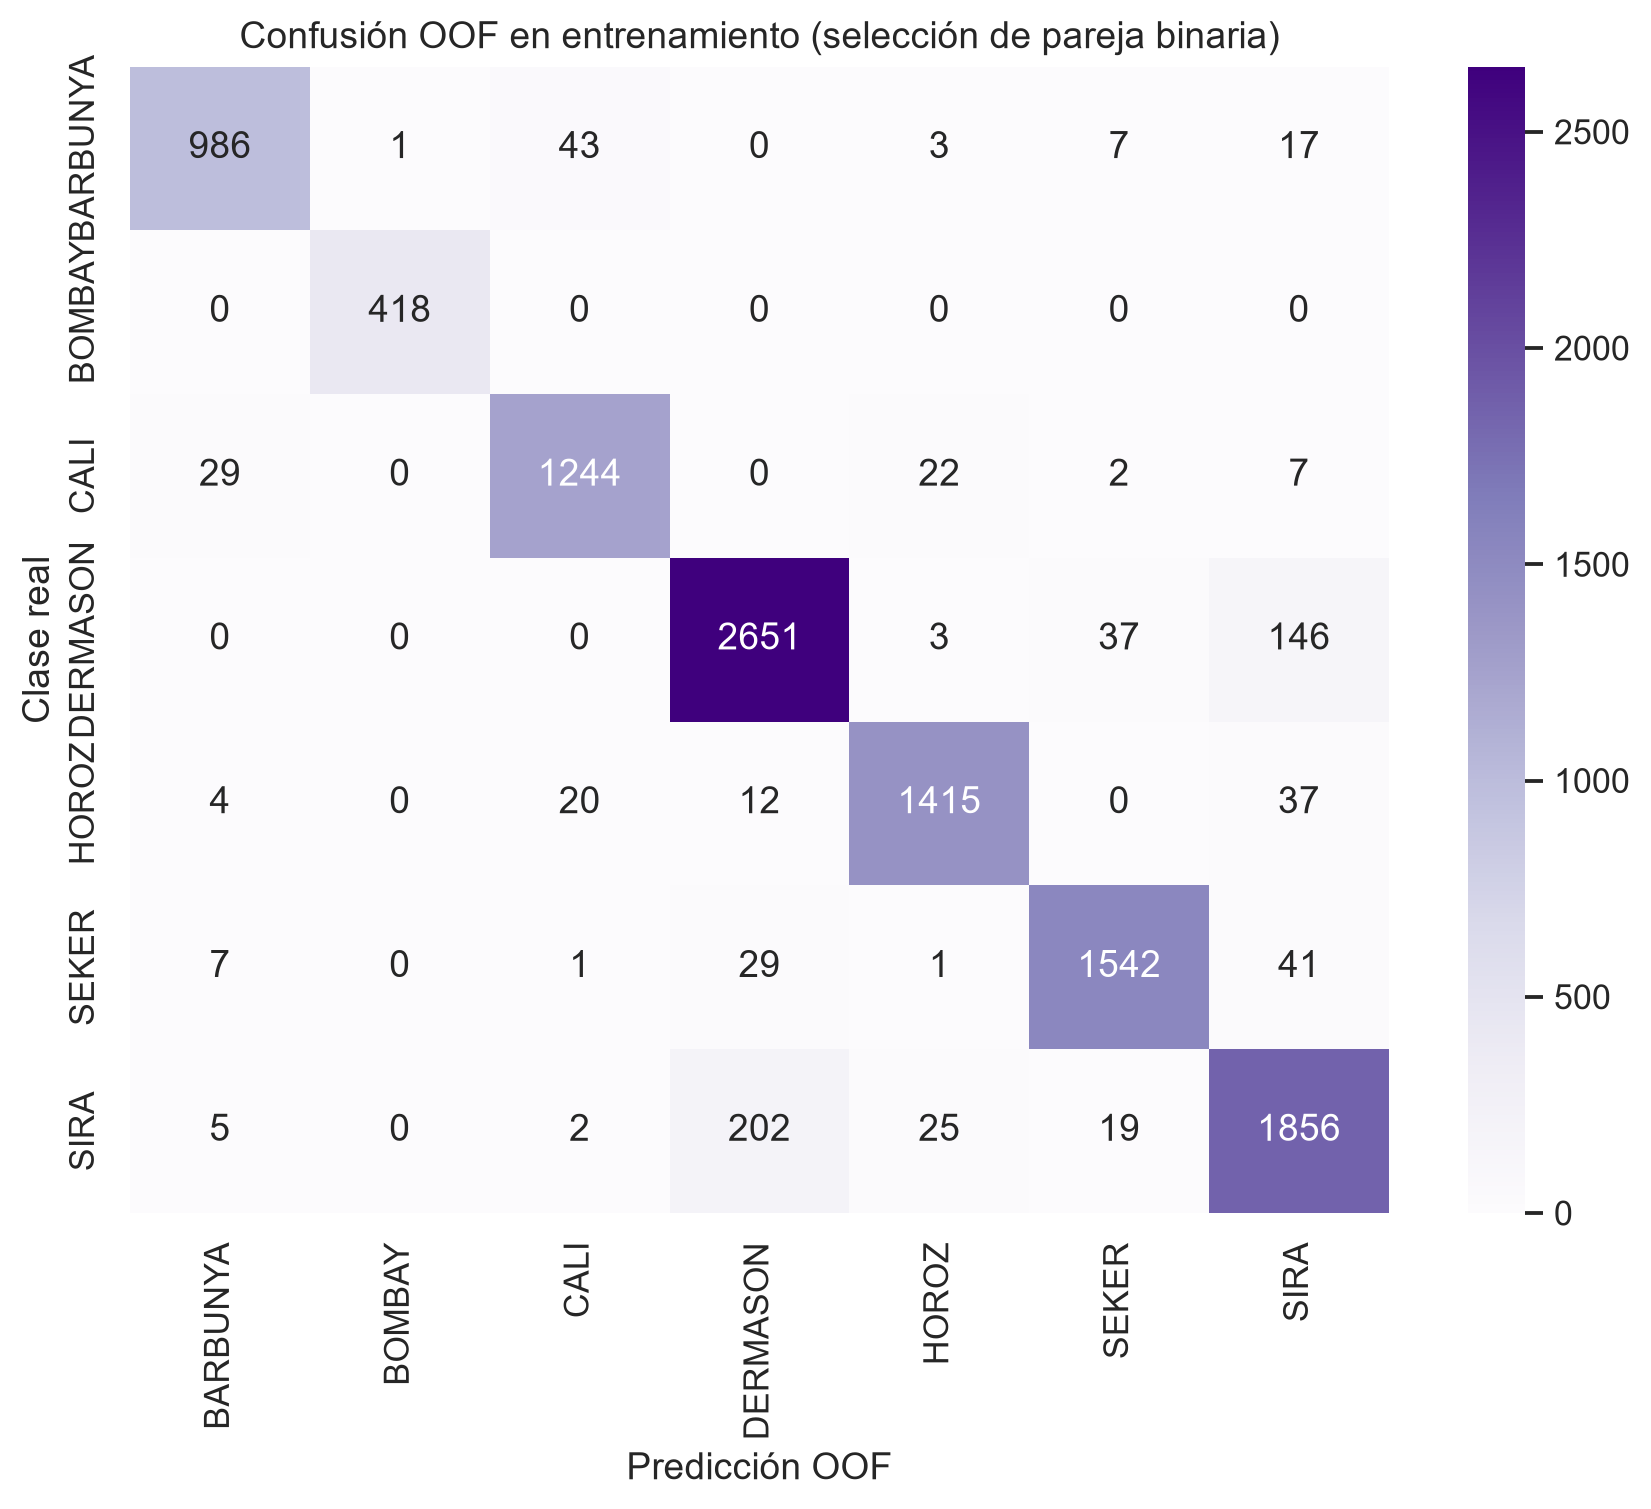

In [6]:
ranking = pd.read_csv(ROOT / "results" / "seleccion_pareja_binaria_oof.csv")
display(ranking.head(10))
print("Pareja seleccionada:", " vs ".join(metrics["binary_selection"]["classes"]))
display(Image(filename=str(ROOT / "figures" / "04_confusion_oof_entrenamiento.png"), width=750))

,kernel,cv_accuracy,cv_f1_macro,test_accuracy,test_f1_macro,support_vectors,best_params
0,Lineal,0.924182,0.922193,0.912621,0.910597,912,"{""svc__C"": 128.0}"
1,Polinomial,0.929641,0.927572,0.913430,0.911079,873,"{""svc__C"": 0.5, ""svc__degree"": 3, ""svc__gamma""..."
2,RBF,0.930450,0.928547,0.918285,0.916286,858,"{""svc__C"": 128.0, ""svc__gamma"": 0.00390625}"


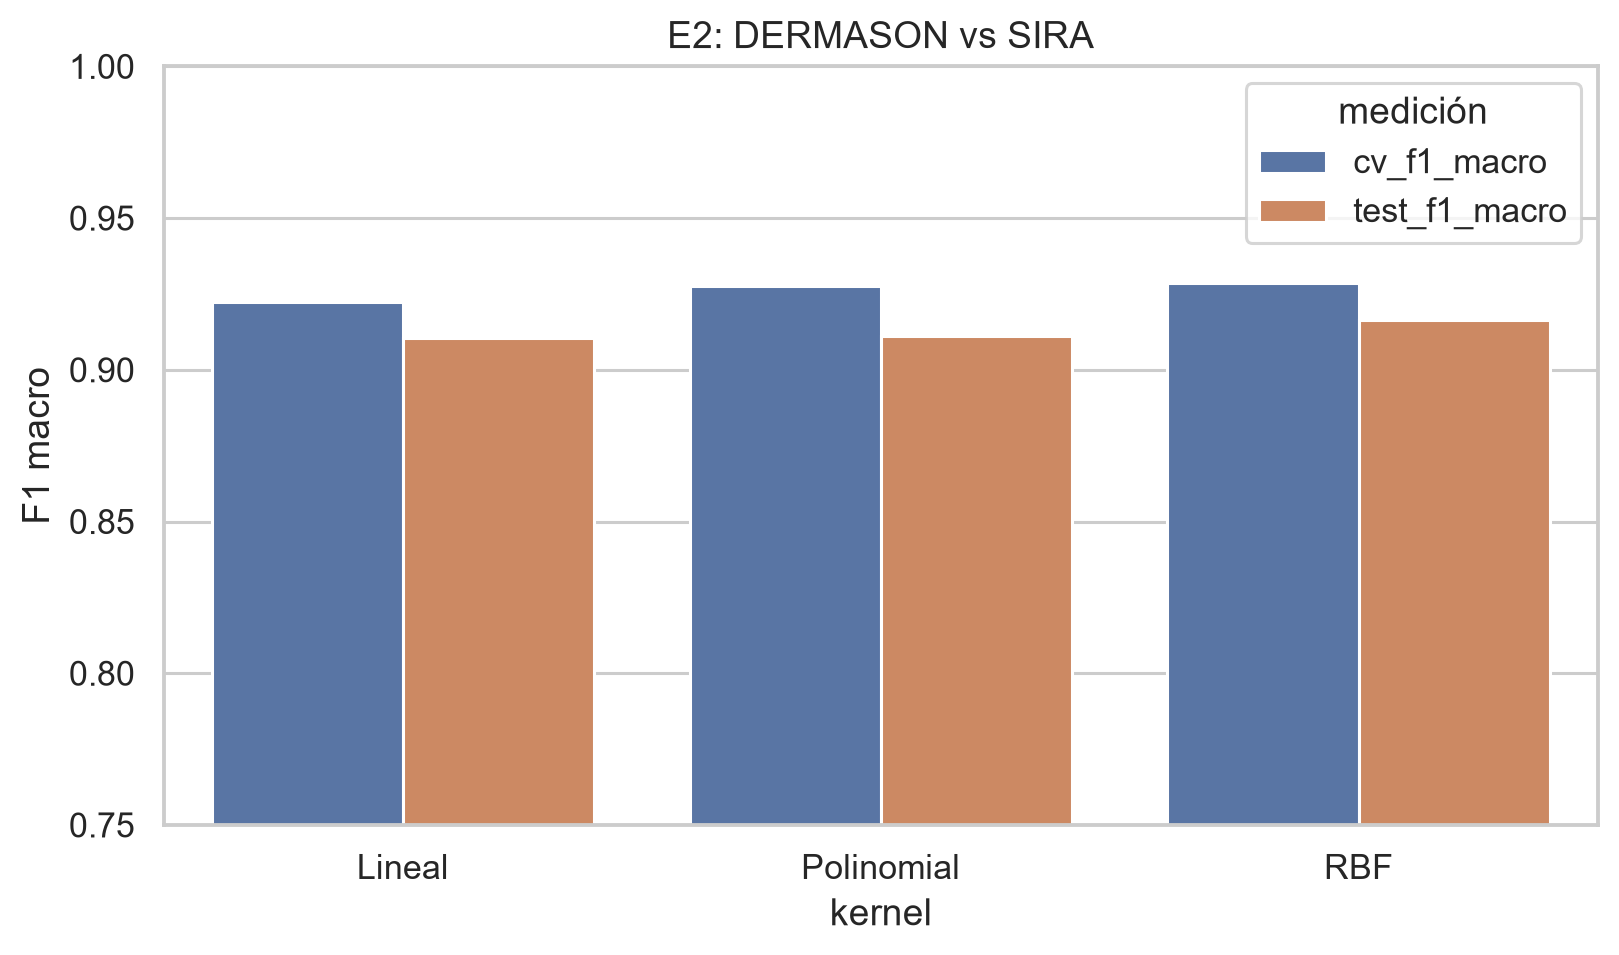

Ganador elegido por CV: RBF (F1=0.9285).
Mayor F1 observado en test: RBF (F1=0.9163).


In [7]:
e2 = pd.read_csv(ROOT / "results" / "e2_resultados_binarios.csv")
display(e2)
display(Image(filename=str(ROOT / "figures" / "05_kernels_binarios.png"), width=750))

ganador_cv = e2.loc[e2["cv_f1_macro"].idxmax()]
ganador_test = e2.loc[e2["test_f1_macro"].idxmax()]
print(f"Ganador elegido por CV: {ganador_cv['kernel']} (F1={ganador_cv['cv_f1_macro']:.4f}).")
print(f"Mayor F1 observado en test: {ganador_test['kernel']} (F1={ganador_test['test_f1_macro']:.4f}).")

**Interpretación:** aquí RBF gana tanto en CV como en el test retenido, pero la diferencia con polinomial es pequeña. La decisión metodológica se apoya en CV; el test solo confirma el desempeño final.

## 5. E3 — Multiclase OvR frente a OvO

- **OvR:** 7 clasificadores, cada clase contra las demás.
- **OvO:** 21 clasificadores, uno por cada pareja.

La implementación NumPy propia se muestra en un subconjunto por su matriz kernel `O(n²)`. La comparación completa usa los envoltorios explícitos de scikit-learn con el mismo `C`, `gamma` y RBF. Cambiar solamente `decision_function_shape` no cambiaría el entrenamiento interno de `SVC`, por eso no se hace eso.

,estrategia,n_entrenamiento,n_prueba,accuracy,f1_macro,fit_s,predict_s,n_modelos_binarios
0,OvR propio,420,210,0.914286,0.930522,0.200662,0.003712,7
1,OvO propio,420,210,0.914286,0.931718,0.104913,0.004341,21


,accuracy,f1_macro,fit_s,predict_s,n_binary_models,support_vectors_sum
OvR,0.922481,0.933728,3.952069,2.366754,7.0,4038.0
OvO,0.923588,0.934961,1.164607,2.710996,21.0,2416.0


,precision,recall,f1-score,support
BARBUNYA,0.923664,0.913208,0.918406,265.000000
BOMBAY,1.000000,1.000000,1.000000,104.000000
CALI,0.929878,0.935583,0.932722,326.000000
DERMASON,0.917018,0.919605,0.918310,709.000000
HOROZ,0.966851,0.940860,0.953678,372.000000
SEKER,0.946341,0.955665,0.950980,406.000000
SIRA,0.866541,0.874763,0.870633,527.000000
accuracy,0.923588,0.923588,0.923588,0.923588
macro avg,0.935756,0.934240,0.934961,2709.000000
weighted avg,0.923820,0.923588,0.923668,2709.000000


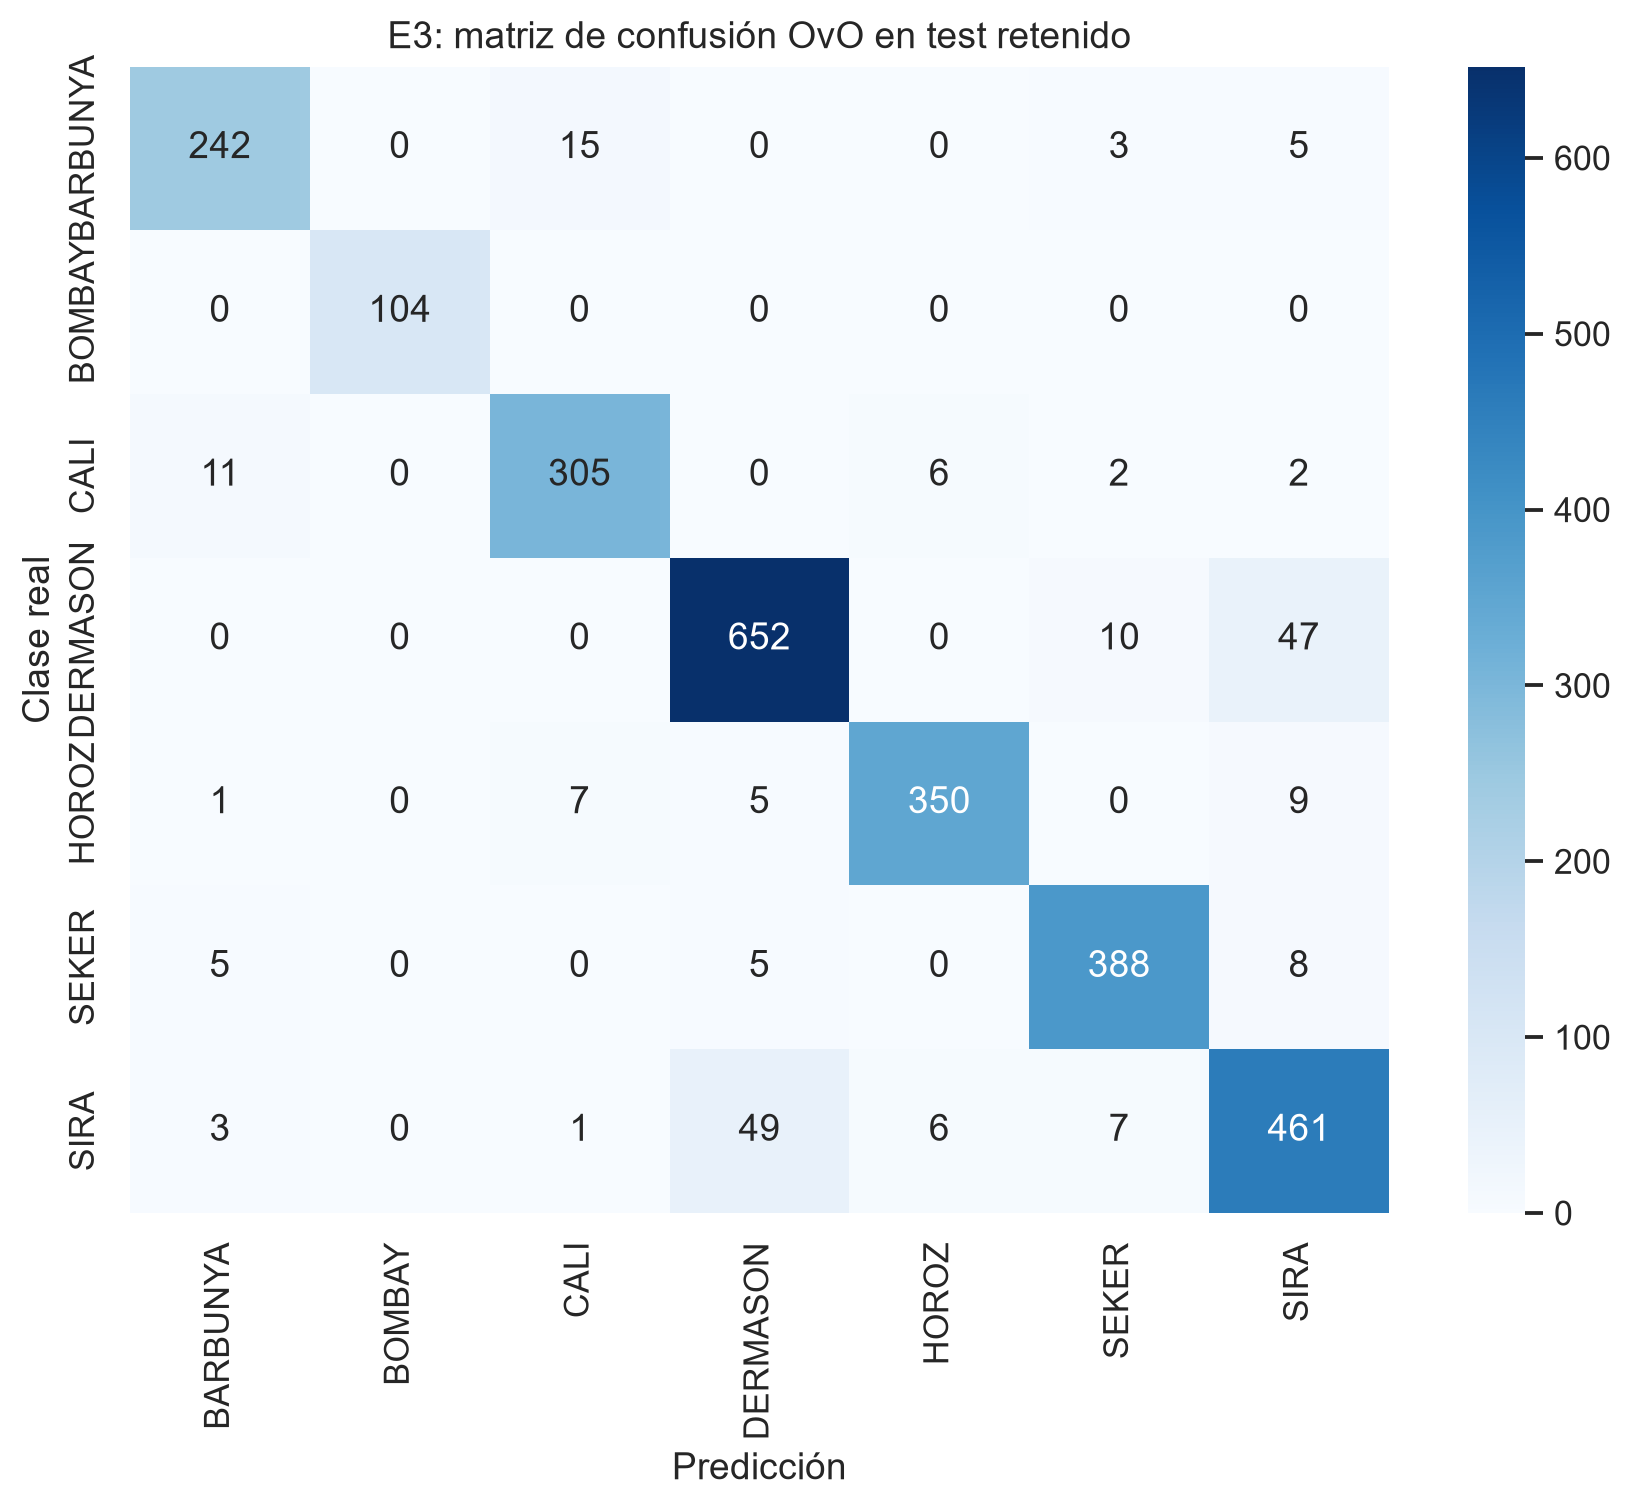

In [8]:
display(pd.read_csv(ROOT / "results" / "e3_multiclase_smo_propio_subconjunto.csv"))
e3 = pd.read_csv(ROOT / "results" / "e3_comparacion_ovr_ovo.csv", index_col=0)
display(e3)
display(pd.read_csv(ROOT / "results" / "e3_reporte_OvO.csv", index_col=0))
display(Image(filename=str(ROOT / "figures" / "07_confusion_ovo_test.png"), width=750))

In [9]:
delta_f1 = e3.loc["OvO", "f1_macro"] - e3.loc["OvR", "f1_macro"]
print(f"Diferencia OvO - OvR en F1 macro: {delta_f1:.4f}.")
print("Conclusión prudente: OvO fue ligeramente mejor en esta partición; la diferencia es pequeña.")

Diferencia OvO - OvR en F1 macro: 0.0012.
Conclusión prudente: OvO fue ligeramente mejor en esta partición; la diferencia es pequeña.


## 6. E4 — Sensibilidad a C y gamma

Los dos primeros mapas usan medias de validación cruzada, no el test. El tercero cuenta vectores soporte al ajustar todo el entrenamiento. Más vectores soporte suele significar una frontera que depende de más ejemplos.

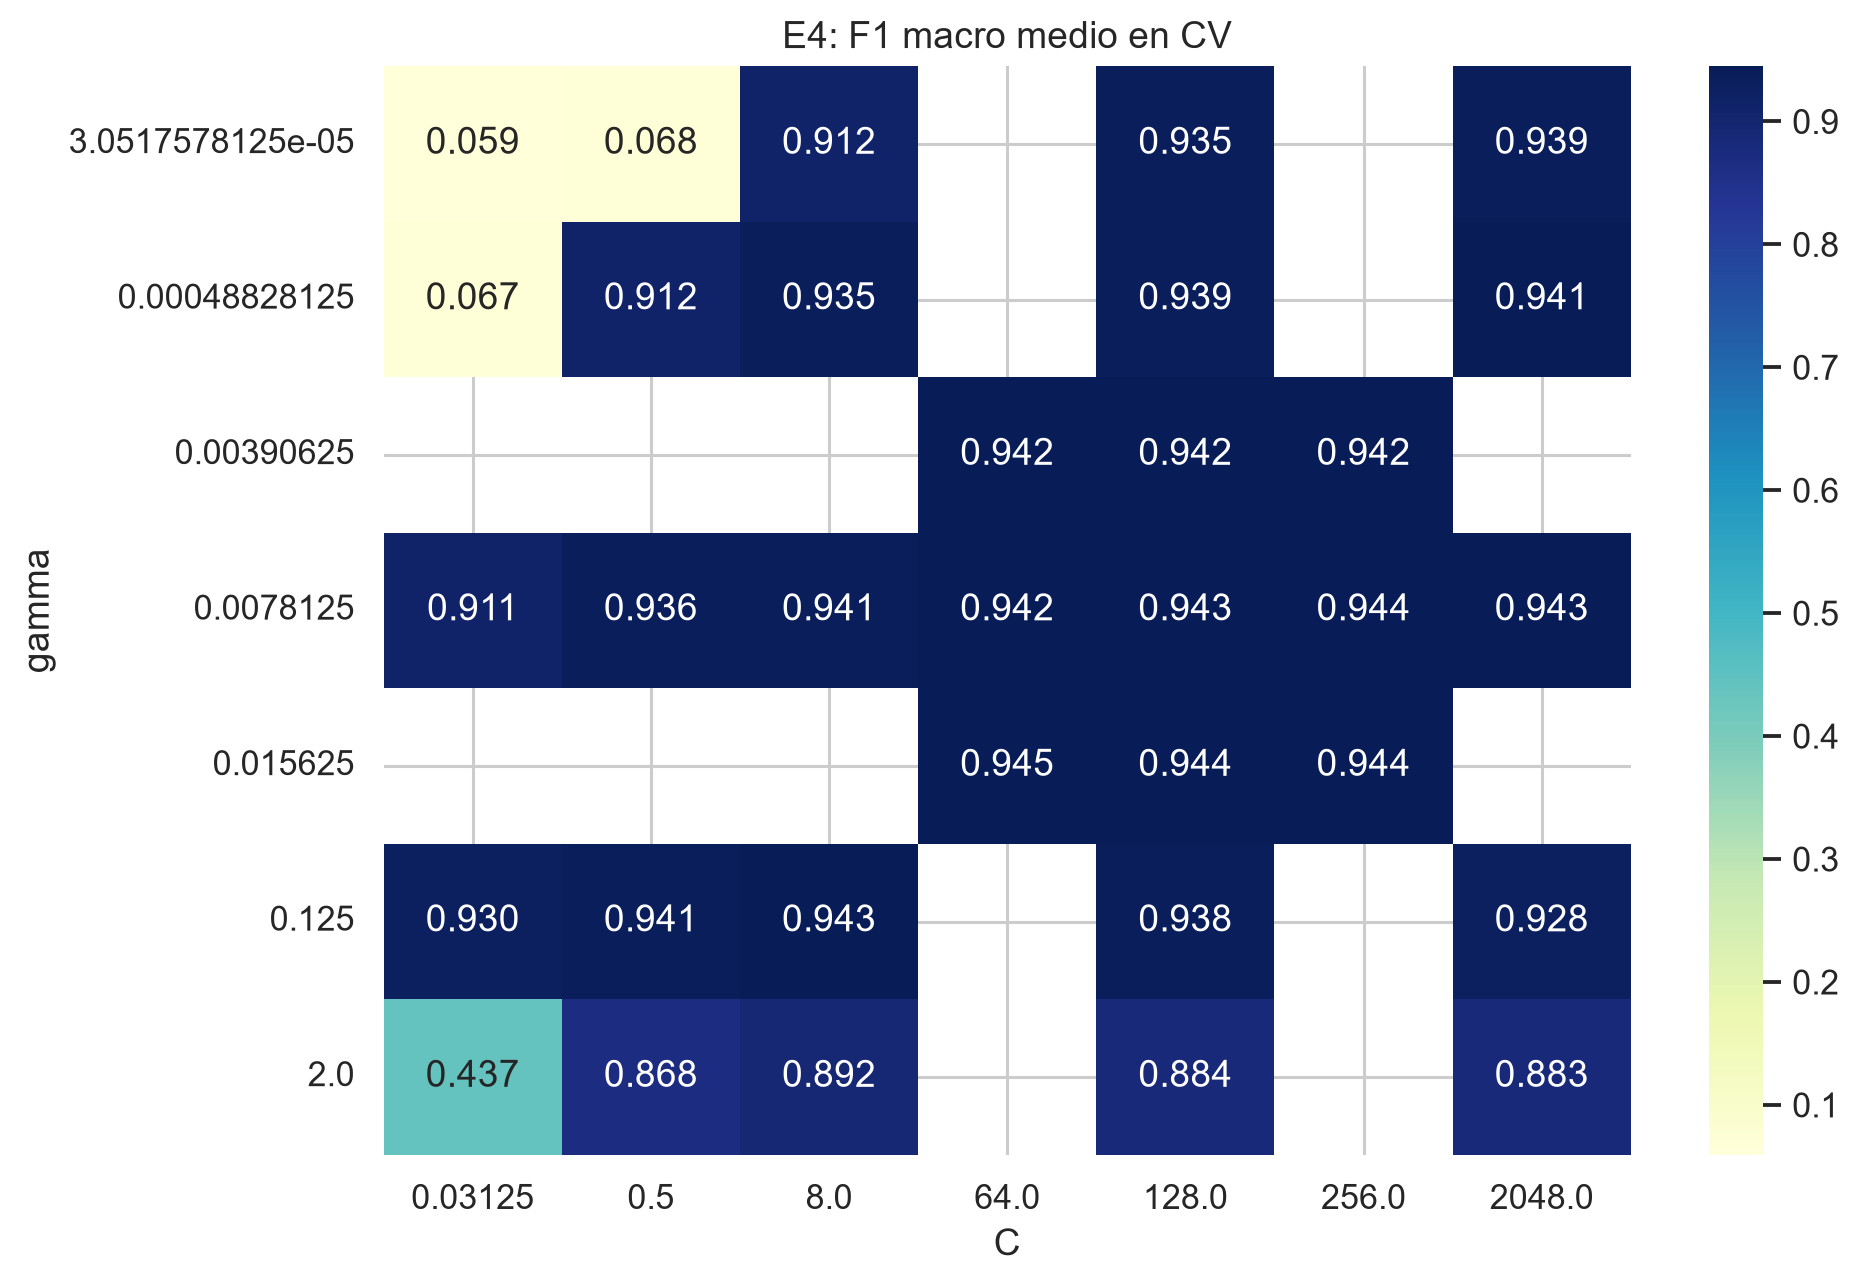

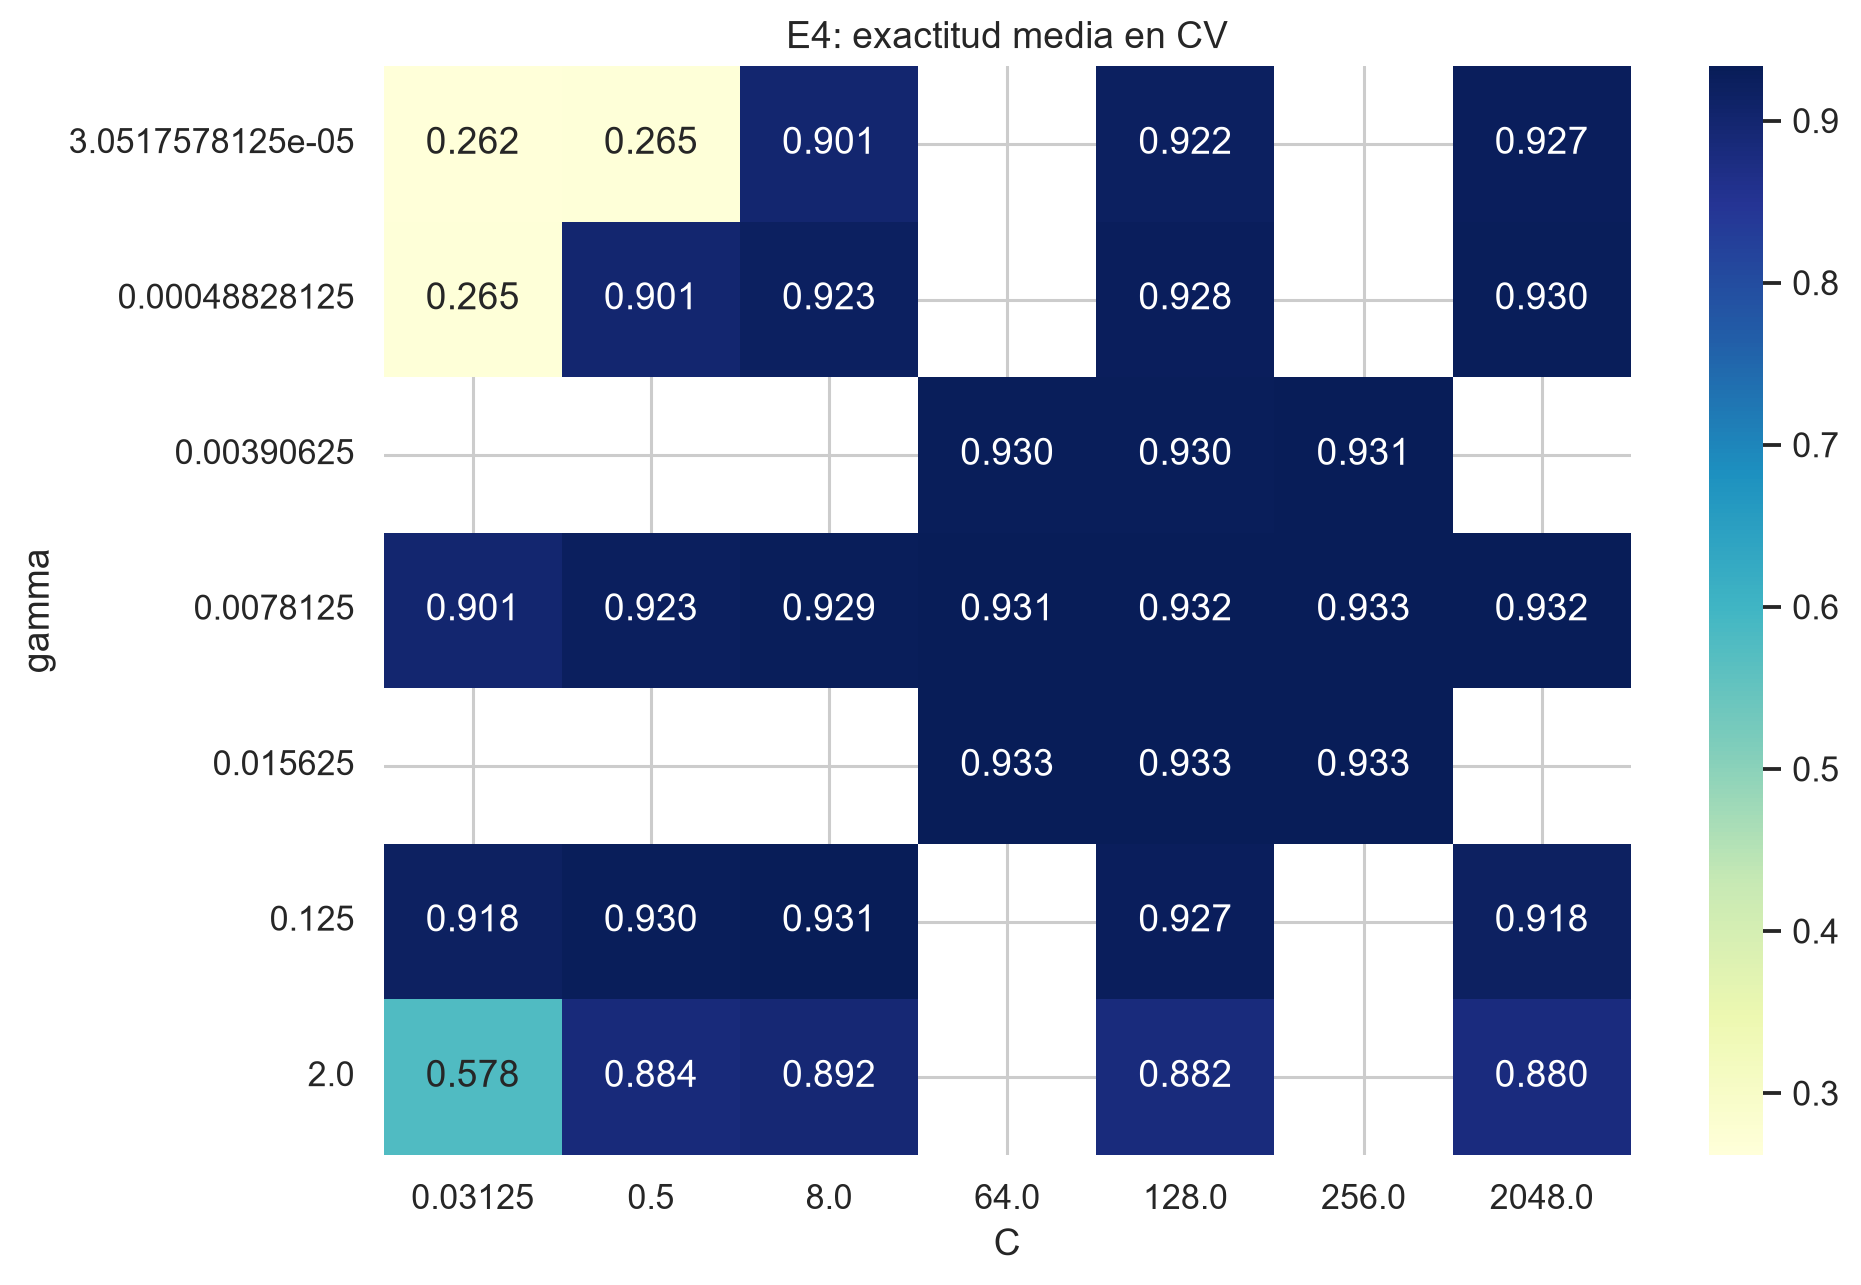

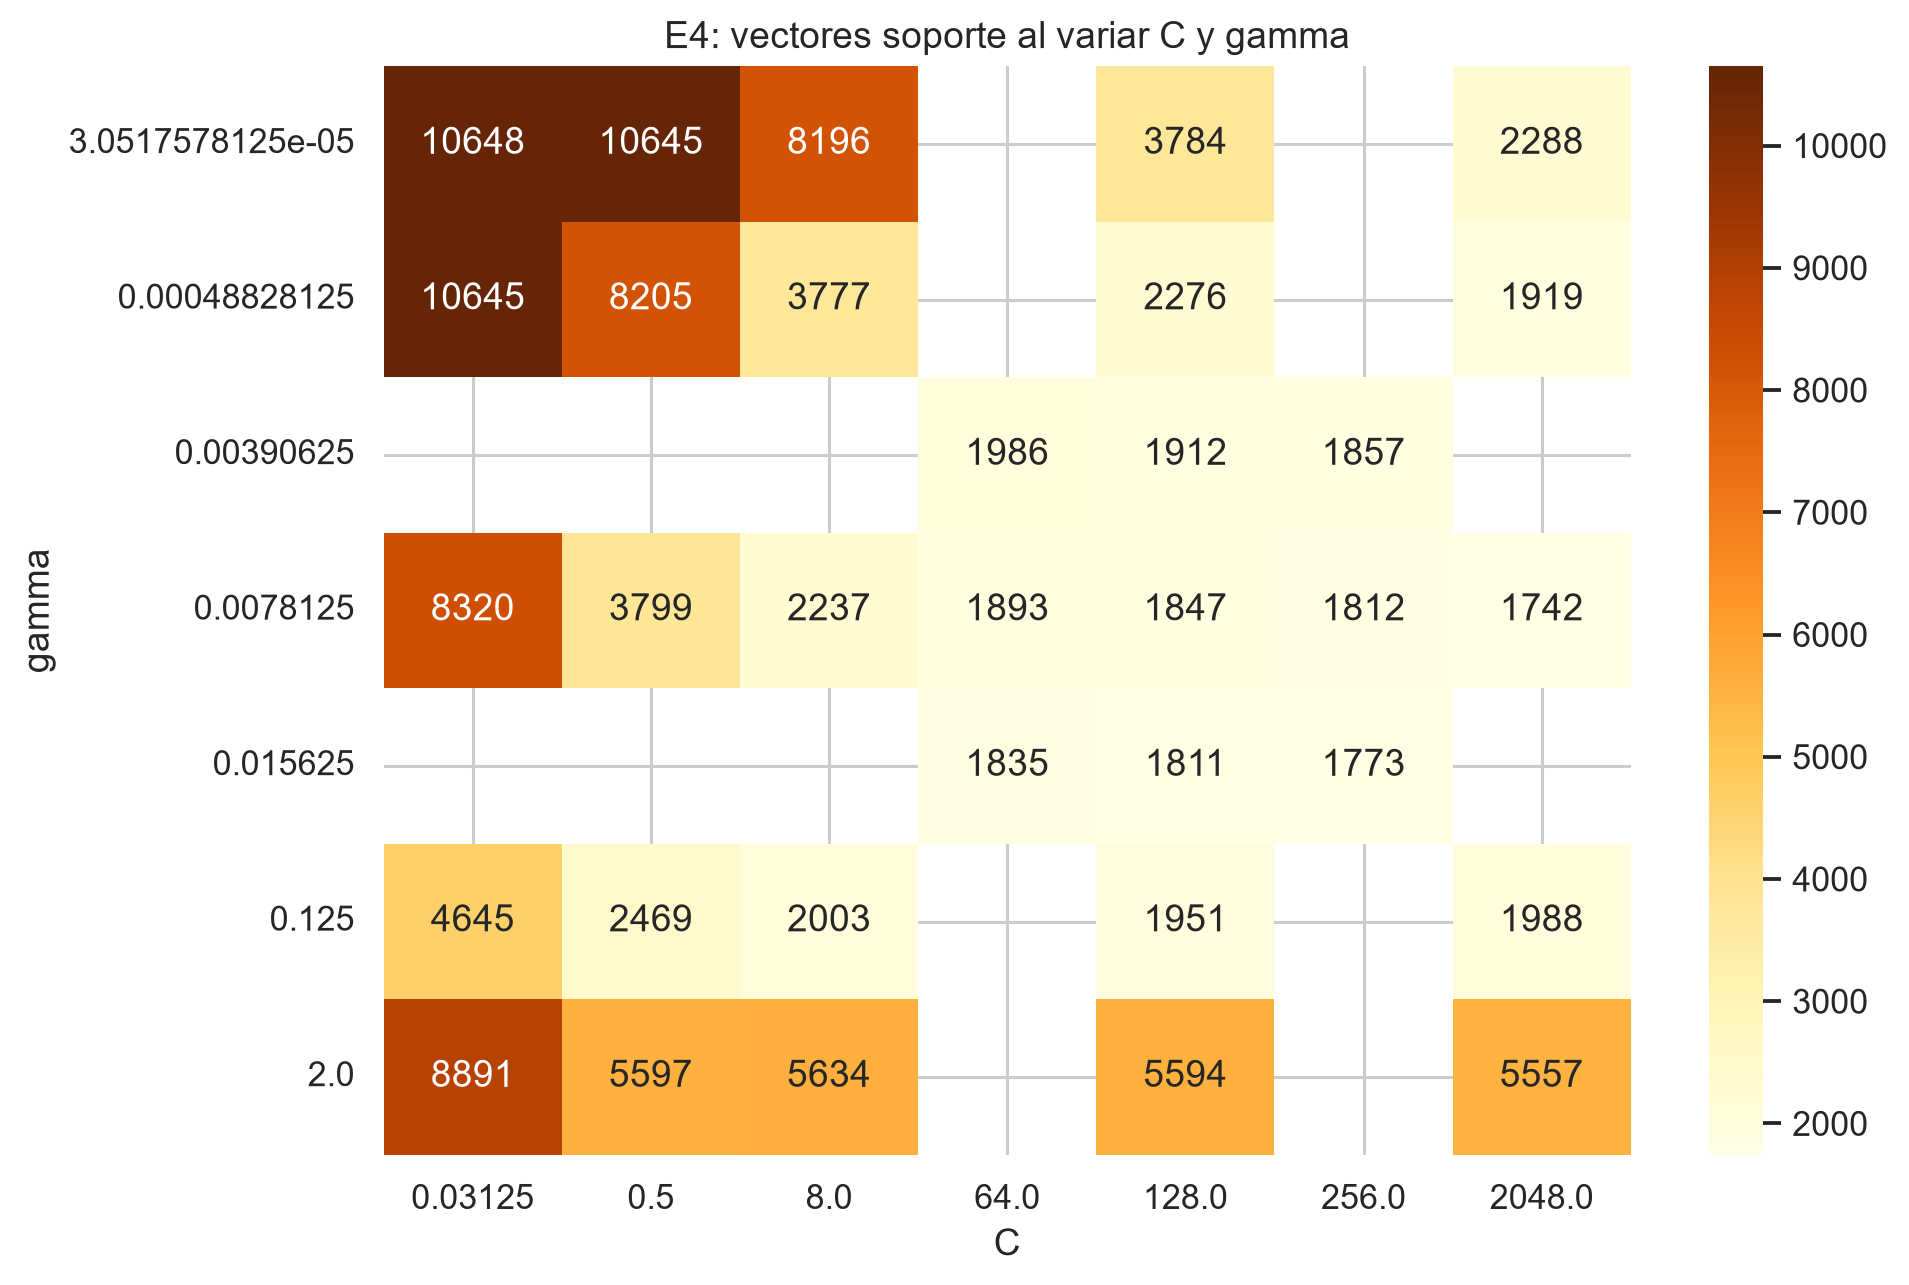

In [10]:
for filename in ["08_heatmap_f1_cv.png", "09_heatmap_accuracy_cv.png", "09b_heatmap_vectores_soporte.png"]:
    display(Image(filename=str(ROOT / "figures" / filename), width=850))

## 7. E5 — Costo computacional

Cada punto de tiempo se midió tres veces. Se reporta la mediana y el rango intercuartílico. El ajuste `T(m)=c·m^theta` es empírico para esta máquina y este rango de tamaños; no es una demostración de complejidad asintótica.

,n_train,strategy,fit_median_s,fit_q1_s,fit_q3_s,predict_median_500_s
0,500,OvO,0.068213,0.067524,0.073610,0.062523
1,500,OvR,0.049796,0.048312,0.053625,0.033673
2,1000,OvO,0.084585,0.083665,0.088588,0.095555
3,1000,OvR,0.115418,0.104896,0.117281,0.059053
4,2000,OvO,0.167339,0.163542,0.192691,0.303247
5,2000,OvR,0.373953,0.373944,0.385382,0.131769
6,4000,OvO,0.288101,0.261337,0.293060,0.187096
7,4000,OvR,0.648494,0.631112,1.262172,0.169061
8,8000,OvO,0.735375,0.655356,0.773939,0.265923
9,8000,OvR,3.395338,3.107094,3.476201,0.295875


,strategy,c,theta,r2_log_log
0,OvO,0.000259,0.862881,0.962157
1,OvR,0.000005,1.467299,0.977807


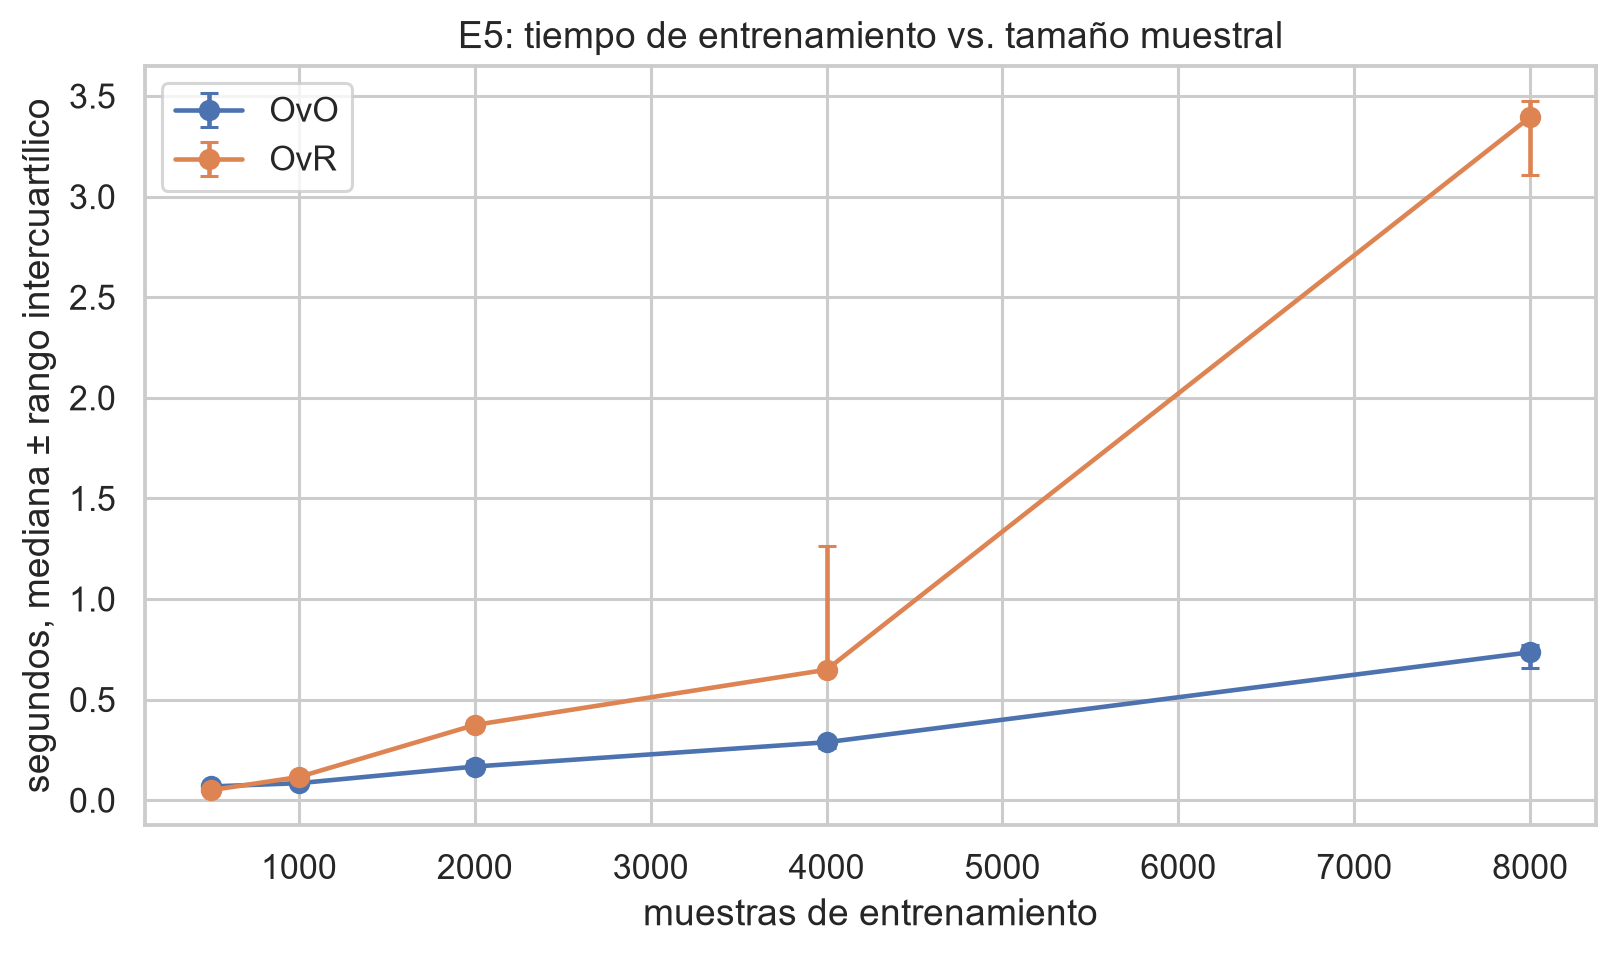

,k,strategy,fit_median_s,predict_median_300_s
0,2,OvO,0.016933,0.012315
1,2,OvR,0.024529,0.008693
2,3,OvO,0.026046,0.020661
3,3,OvR,0.041100,0.018503
4,4,OvO,0.027777,0.022545
5,4,OvR,0.047529,0.015968
6,5,OvO,0.035625,0.027499
7,5,OvR,0.038798,0.013739
8,6,OvO,0.044118,0.032838
9,6,OvR,0.047573,0.017247


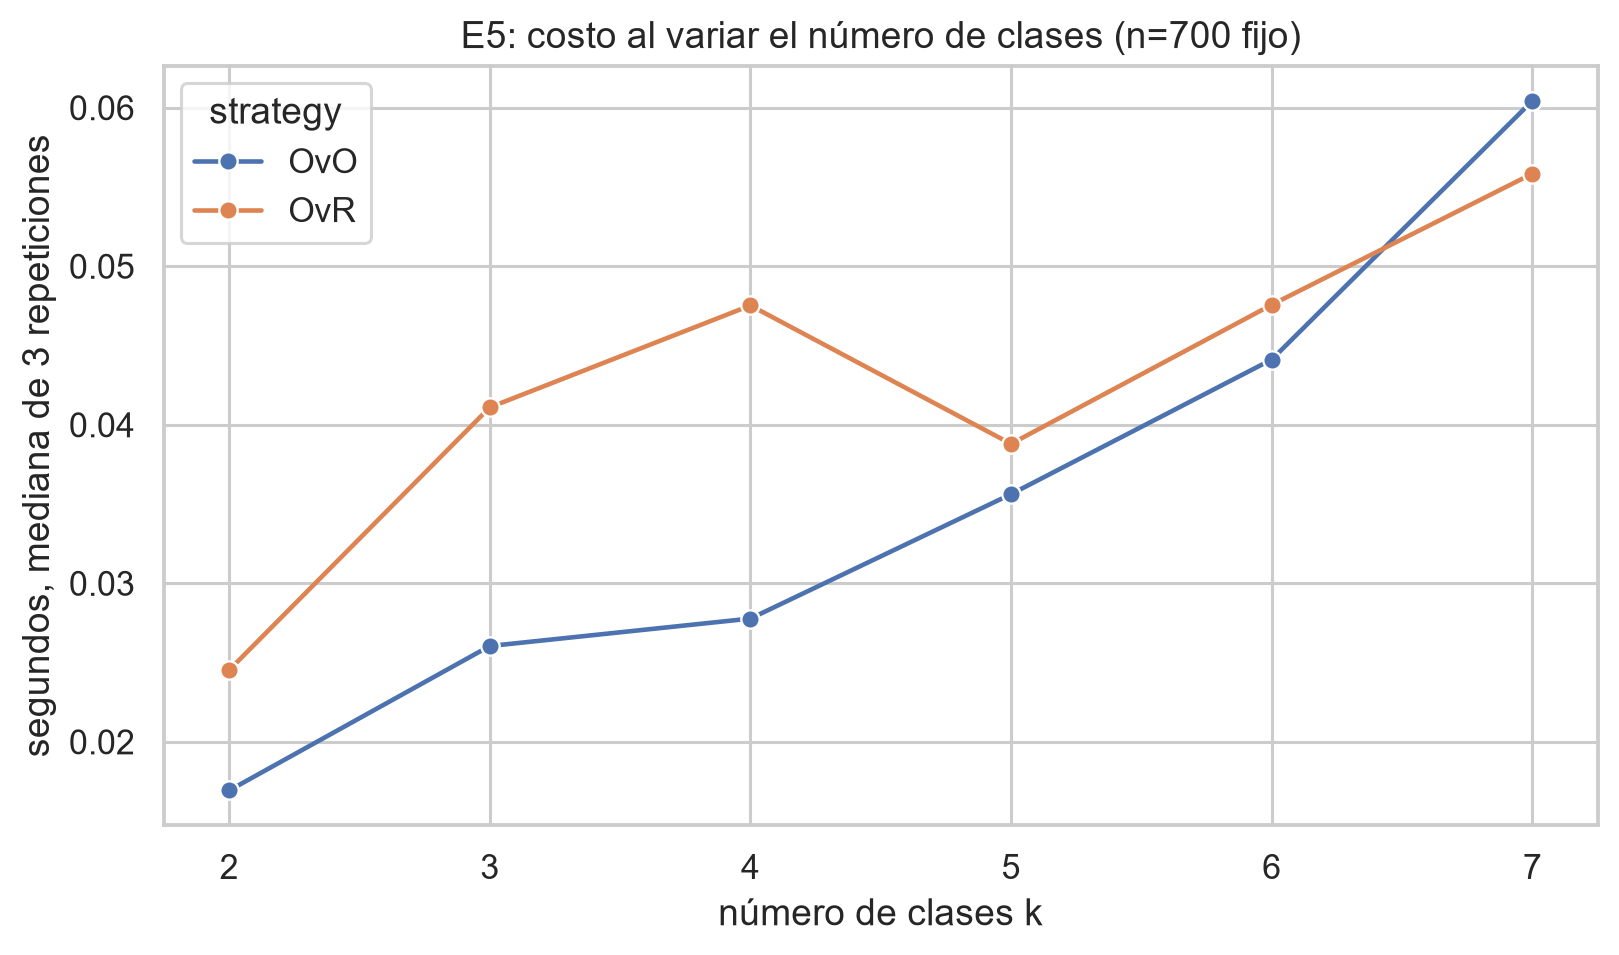

In [11]:
display(pd.read_csv(ROOT / "results" / "e5_tiempos_resumen.csv"))
display(pd.read_csv(ROOT / "results" / "e5_ajuste_potencia.csv"))
display(Image(filename=str(ROOT / "figures" / "10_tiempo_vs_n.png"), width=750))
display(pd.read_csv(ROOT / "results" / "e5_tiempos_por_k_resumen.csv"))
display(Image(filename=str(ROOT / "figures" / "11_tiempo_vs_k.png"), width=750))

## 8. Conclusiones que sí permiten los datos

1. La limpieza correcta deja 13 543 observaciones y no requiere imputación.
2. DERMASON–SIRA es la pareja más confundida según predicciones OOF de entrenamiento.
3. RBF obtiene el mejor F1 macro binario por CV y también el mejor resultado de test en esta corrida.
4. OvO queda apenas por encima de OvR en el test; no hay evidencia para afirmar superioridad universal.
5. El SMO propio coincide con LIBSVM en la verificación acotada, pero los experimentos completos usan `SVC` por eficiencia.
6. Los tiempos dependen del equipo; `theta` describe esta corrida, no una ley teórica.

## 9. Qué debe entrar luego al informe LaTeX

- tabla de datos originales vs. analíticos y conteos por clase;
- explicación explícita de los 68 duplicados y cero faltantes;
- protocolo 80/20, semilla 42, CV de 5 pliegues y política de test único;
- tabla E1 con objetivo dual, `m-M`, residuo, diferencia de scores y concordancia;
- matriz OOF que justifica DERMASON–SIRA;
- tabla E2 con CV/test y vectores soporte;
- tabla y matriz E3 para OvR/OvO;
- tres mapas E4: F1, exactitud y vectores soporte;
- curvas E5, repeticiones, mediana/IQR, `theta` y `R²`;
- limitaciones: datos tabulares extraídos de imágenes, una sola partición externa y SMO propio validado en subconjunto.